# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [3]:
# Part 1
# Build the card and shoe classes for a blackjack game using multiple decks.

import random

class Card:
    """Simple playing card object."""
    
    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit
    
    def blackjack_value(self):
        """Return the blackjack value of this card."""
        if self.rank in ["J", "Q", "K"]:
            return 10
        if self.rank == "A":
            return 11
        return int(self.rank)
    
    def count_value(self):
        """
        Hi-Lo style counting:
        2-6 = +1
        7-9 = 0
        10-A = -1
        """
        if self.rank in ["2", "3", "4", "5", "6"]:
            return 1
        if self.rank in ["7", "8", "9"]:
            return 0
        return -1
    
    def __repr__(self):
        return f"{self.rank}{self.suit}"


class Shoe:
    """
    Blackjack shoe with multiple decks.
    I also added a plastic card marker.
    Once the plastic card is reached, the shoe is reshuffled before the next round.
    """
    
    SUITS = ["♠", "♥", "♦", "♣"]
    RANKS = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]
    
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.cut_index = None
        self.reshuffle_needed = False
        self.build_shoe()
    
    def build_shoe(self):
        """Create a fresh shuffled shoe and place the plastic card randomly."""
        self.cards = []
        for _ in range(self.num_decks):
            for suit in self.SUITS:
                for rank in self.RANKS:
                    self.cards.append(Card(rank, suit))
        
        random.shuffle(self.cards)
        
        # Put the plastic card somewhere near the back half of the shoe
        # so the shoe does not last too long.
        low = len(self.cards) // 2
        high = len(self.cards) - 20
        self.cut_index = random.randint(low, high)
        self.reshuffle_needed = False
    
    def shuffle(self):
        """Shuffle the shoe again."""
        self.build_shoe()
    
    def draw(self):
        """Draw the top card from the shoe."""
        if len(self.cards) == 0:
            self.shuffle()
        
        card = self.cards.pop(0)
        
        # If we have reached/passed the plastic card point, mark for reshuffle later
        dealt_so_far = self.num_decks * 52 - len(self.cards)
        if dealt_so_far >= self.cut_index:
            self.reshuffle_needed = True
        
        return card
    
    def cards_left(self):
        return len(self.cards)

In [4]:
# Test cell

shoe = Shoe(num_decks=2)

print("Cards left at start:", shoe.cards_left())
print("First 5 cards:")
for _ in range(5):
    print(shoe.draw())

print("Cards left after drawing 5:", shoe.cards_left())
print("Reshuffle needed yet?", shoe.reshuffle_needed)

Cards left at start: 104
First 5 cards:
8♦
5♦
Q♦
2♥
3♠
Cards left after drawing 5: 99
Reshuffle needed yet? False


2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

In [5]:
# Part 2
# I cannot directly make the PDF here, but I can give the UML text.
# You can paste this into mermaid.live or draw.io and export it as a PDF for submission.

uml_text = r"""
classDiagram

class Card {
    - rank
    - suit
    + blackjack_value()
    + count_value()
}

class Shoe {
    - num_decks
    - cards
    - cut_index
    - reshuffle_needed
    + build_shoe()
    + shuffle()
    + draw()
    + cards_left()
}

class Hand {
    - cards
    + add_card(card)
    + value()
    + is_blackjack()
    + is_bust()
    + clear()
}

class Player {
    - name
    - chips
    - bet_amount
    - hand
    - shown_cards
    + reset_hand()
    + receive_card(card)
    + place_bet()
    + wants_hit(dealer_upcard)
    + observe_card(card)
    + settle_result(result)
}

class Dealer {
    + wants_hit(dealer_upcard)
}

class HumanPlayer {
    + wants_hit(dealer_upcard)
}

class CountingPlayer {
    - threshold
    + running_count()
    + wants_hit(dealer_upcard)
}

class BlackjackGame {
    - shoe
    - players
    - dealer
    - verbose
    + initial_deal()
    + play_player_turns()
    + play_dealer_turn()
    + settle_bets()
    + play_round()
    + play_many_rounds(n_rounds)
}

Shoe --> Card
Hand --> Card
Player --> Hand
Dealer --|> Player
HumanPlayer --|> Player
CountingPlayer --|> Player
BlackjackGame --> Shoe
BlackjackGame --> Dealer
BlackjackGame --> Player
"""

print(uml_text)


classDiagram

class Card {
    - rank
    - suit
    + blackjack_value()
    + count_value()
}

class Shoe {
    - num_decks
    - cards
    - cut_index
    - reshuffle_needed
    + build_shoe()
    + shuffle()
    + draw()
    + cards_left()
}

class Hand {
    - cards
    + add_card(card)
    + value()
    + is_blackjack()
    + is_bust()
    + clear()
}

class Player {
    - name
    - chips
    - bet_amount
    - hand
    - shown_cards
    + reset_hand()
    + receive_card(card)
    + place_bet()
    + wants_hit(dealer_upcard)
    + observe_card(card)
    + settle_result(result)
}

class Dealer {
    + wants_hit(dealer_upcard)
}

class HumanPlayer {
    + wants_hit(dealer_upcard)
}

class CountingPlayer {
    - threshold
    + running_count()
    + wants_hit(dealer_upcard)
}

class BlackjackGame {
    - shoe
    - players
    - dealer
    - verbose
    + initial_deal()
    + play_player_turns()
    + play_dealer_turn()
    + settle_bets()
    + play_round()
    + play_many_rounds(

In [6]:
# Test cell for Part 2

print("UML text is ready.")
print("Length of UML text:", len(uml_text))

UML text is ready.
Length of UML text: 1200


3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [10]:
# Part 3
# In this part, I am only setting up the structure (skeleton) of the classes.
# I am NOT implementing the logic yet, just defining what each class will have.
# This helps plan out the full program before coding everything.

class HandSkeleton:
    def __init__(self):
        # This will store the cards in the player's hand
        self.cards = []
    
    def add_card(self, card):
        # Add a card to the hand
        pass
    
    def value(self):
        # Calculate the total blackjack value of the hand
        pass
    
    def is_blackjack(self):
        # Check if the hand is a blackjack (21 with 2 cards)
        pass
    
    def is_bust(self):
        # Check if the hand value is over 21
        pass
    
    def clear(self):
        # Reset the hand for a new round
        pass


class PlayerSkeleton:
    def __init__(self, name, chips=100):
        # Basic info about the player
        self.name = name
        self.chips = chips
        
        # Default bet amount (can change later if needed)
        self.bet_amount = 10
        
        # Each player will have a hand
        self.hand = None
        
        # This will store all visible cards for card counting
        self.shown_cards = []
    
    def reset_hand(self):
        # Reset the player's hand at the start of a round
        pass
    
    def receive_card(self, card):
        # Add a card to the player's hand
        pass
    
    def place_bet(self):
        # Deduct chips and place a bet
        pass
    
    def wants_hit(self, dealer_upcard=None):
        # Decide whether the player wants another card
        pass
    
    def observe_card(self, card):
        # Keep track of all cards that are visible
        pass
    
    def settle_result(self, result):
        # Update chips based on win/lose/push
        pass


class DealerSkeleton(PlayerSkeleton):
    # Dealer inherits from Player but follows fixed rules
    
    def wants_hit(self, dealer_upcard=None):
        # Dealer decision logic (usually hit on 16, stand on 17)
        pass


class HumanPlayerSkeleton(PlayerSkeleton):
    # This class will allow user input
    
    def wants_hit(self, dealer_upcard=None):
        # Ask the user whether they want to hit or stand
        pass


class CountingPlayerSkeleton(PlayerSkeleton):
    # This player will use card counting strategy
    
    def __init__(self, name, chips=100, threshold=0):
        super().__init__(name, chips)
        
        # Threshold controls when to hit or stand
        self.threshold = threshold
    
    def running_count(self):
        # Calculate the total count based on seen cards
        pass
    
    def wants_hit(self, dealer_upcard=None):
        # Use the running count to decide hit or stand
        pass


class BlackjackGameSkeleton:
    def __init__(self, players, shoe=None, verbose=True):
        # Store players, dealer, and shoe
        self.players = players
        self.dealer = None
        self.shoe = shoe
        self.verbose = verbose
    
    def initial_deal(self):
        # Deal initial 2 cards to each player and dealer
        pass
    
    def play_player_turns(self):
        # Handle each player's turn
        pass
    
    def play_dealer_turn(self):
        # Handle dealer's turn
        pass
    
    def settle_bets(self):
        # Compare hands and update chips
        pass
    
    def play_round(self):
        # Run a full round of blackjack
        pass
    
    def play_many_rounds(self, n_rounds):
        # Run multiple rounds of the game
        pass

In [11]:
# Test cell (just checking that objects can be created)

p = PlayerSkeleton("Test Player", chips=100)
c = CountingPlayerSkeleton("Counter", chips=150, threshold=-1)

print("Player created:", p.name, "| Chips:", p.chips)
print("Counting player threshold:", c.threshold)

Player created: Test Player | Chips: 100
Counting player threshold: -1


4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [12]:
# Part 4
# In this part, I am now implementing the full logic of the blackjack game.
# I am keeping the rules simple so it is easier to follow:
# - No splitting or doubling
# - Dealer hits on 16 and stands on 17
# - Blackjack pays 3:2

class Hand:
    """Represents a single blackjack hand."""
    
    def __init__(self):
        # This will store all cards in the hand
        self.cards = []
    
    def add_card(self, card):
        # Add a new card to the hand
        self.cards.append(card)
    
    def value(self):
        # Calculate total value of the hand
        total = sum(card.blackjack_value() for card in self.cards)
        
        # Count how many aces we have
        aces = sum(1 for card in self.cards if card.rank == "A")
        
        # If total > 21, convert some aces from 11 to 1
        # This prevents unnecessary busting
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        
        return total
    
    def is_blackjack(self):
        # Blackjack means exactly 2 cards totaling 21
        return len(self.cards) == 2 and self.value() == 21
    
    def is_bust(self):
        # Bust means the hand is over 21
        return self.value() > 21
    
    def clear(self):
        # Reset the hand for the next round
        self.cards = []
    
    def __repr__(self):
        # Nice readable format when printing
        return f"{self.cards} (value={self.value()})"


class Player:
    """Base player class used for both AI players and human player."""
    
    def __init__(self, name, chips=100, bet_amount=10):
        # Basic player info
        self.name = name
        self.chips = chips
        self.bet_amount = bet_amount
        
        # Each player has a hand
        self.hand = Hand()
        
        # Store all visible cards for counting strategy
        self.shown_cards = []
    
    def reset_hand(self):
        # Clear hand at start of a new round
        self.hand.clear()
    
    def receive_card(self, card):
        # Add a card to the player's hand
        self.hand.add_card(card)
    
    def place_bet(self):
        # Deduct bet amount from chips if possible
        if self.chips >= self.bet_amount:
            self.chips -= self.bet_amount
            return self.bet_amount
        
        # If not enough chips, player cannot bet
        return 0
    
    def observe_card(self, card):
        # Store all visible cards for card counting
        self.shown_cards.append(card)
    
    def wants_hit(self, dealer_upcard=None):
        # Basic strategy: hit if 16 or less
        return self.hand.value() <= 16
    
    def settle_result(self, result, bet):
        # Update chips based on result
        if result == "win":
            self.chips += 2 * bet
        elif result == "push":
            self.chips += bet
        elif result == "blackjack":
            self.chips += int(2.5 * bet)
        # If lose → nothing is added back
    
    def __repr__(self):
        return f"{self.name}: chips={self.chips}, hand={self.hand}"


class Dealer(Player):
    """Dealer follows fixed casino rules."""
    
    def __init__(self):
        super().__init__(name="Dealer", chips=0, bet_amount=0)
    
    def wants_hit(self, dealer_upcard=None):
        # Dealer hits on 16 or lower, stands on 17+
        return self.hand.value() <= 16


class HumanPlayer(Player):
    """Allows a human to play using input."""
    
    def wants_hit(self, dealer_upcard=None):
        # Ask the user what they want to do
        while True:
            print(f"\n{self.name}'s hand:", self.hand.cards, "value =", self.hand.value())
            if dealer_upcard:
                print("Dealer upcard:", dealer_upcard)
            
            choice = input("Hit or stand? (h/s): ").lower()
            
            if choice in ["h", "hit"]:
                return True
            if choice in ["s", "stand"]:
                return False
            
            print("Invalid input, please enter h or s.")


class CountingPlayer(Player):
    """Player that uses a simple card counting strategy."""
    
    def __init__(self, name, chips=100, bet_amount=10, threshold=0):
        super().__init__(name, chips, bet_amount)
        
        # Threshold determines how aggressive/conservative the player is
        self.threshold = threshold
    
    def running_count(self):
        # Sum up all count values of visible cards
        return sum(card.count_value() for card in self.shown_cards)
    
    def wants_hit(self, dealer_upcard=None):
        total = self.hand.value()
        count = self.running_count()
        
        # Always hit small totals
        if total <= 11:
            return True
        
        # Always stand on strong totals
        if total >= 17:
            return False
        
        # Use the counting strategy for middle values
        return count <= self.threshold


class BlackjackGame:
    """Main game logic class."""
    
    def __init__(self, players, shoe=None, verbose=True):
        self.players = players
        self.dealer = Dealer()
        self.shoe = shoe if shoe else Shoe(num_decks=6)
        self.verbose = verbose
    
    def log(self, *args):
        # Only print if verbose is True
        if self.verbose:
            print(*args)
    
    def all_players(self):
        # Return all participants including dealer
        return self.players + [self.dealer]
    
    def reset_round(self):
        # Reset hands and reshuffle if needed
        if self.shoe.reshuffle_needed:
            self.log("\nReshuffling shoe...\n")
            self.shoe.shuffle()
        
        for p in self.all_players():
            p.reset_hand()
            p.shown_cards = []
    
    def deal_card(self, player):
        # Deal one card and update all players' knowledge
        card = self.shoe.draw()
        player.receive_card(card)
        
        # Everyone sees the card (simplified for lab)
        for observer in self.all_players():
            observer.observe_card(card)
        
        return card
    
    def initial_deal(self):
        # Deal 2 cards to everyone
        for _ in range(2):
            for p in self.players:
                self.deal_card(p)
            self.deal_card(self.dealer)
    
    def player_turns(self):
        dealer_upcard = self.dealer.hand.cards[0]
        
        for p in self.players:
            while not p.hand.is_bust() and p.wants_hit(dealer_upcard):
                self.log(p.name, "hits")
                self.deal_card(p)
            
            if p.hand.is_bust():
                self.log(p.name, "busted")
            else:
                self.log(p.name, "stands with", p.hand.value())
    
    def dealer_turn(self):
        while not self.dealer.hand.is_bust() and self.dealer.wants_hit():
            self.log("Dealer hits")
            self.deal_card(self.dealer)
        
        if self.dealer.hand.is_bust():
            self.log("Dealer busted")
        else:
            self.log("Dealer stands with", self.dealer.hand.value())
    
    def settle(self, bets):
        dealer_val = self.dealer.hand.value()
        
        for p, bet in bets.items():
            if bet == 0:
                continue
            
            player_val = p.hand.value()
            
            if p.hand.is_bust():
                result = "lose"
            elif self.dealer.hand.is_bust():
                result = "win"
            elif player_val > dealer_val:
                result = "win"
            elif player_val < dealer_val:
                result = "lose"
            else:
                result = "push"
            
            p.settle_result(result, bet)
            self.log(p.name, "->", result, "| chips:", p.chips)
    
    def play_round(self):
        # Remove players with no chips
        self.players = [p for p in self.players if p.chips >= p.bet_amount]
        
        if not self.players:
            self.log("No players left")
            return False
        
        self.reset_round()
        
        # Collect bets
        bets = {}
        for p in self.players:
            bets[p] = p.place_bet()
        
        self.initial_deal()
        self.player_turns()
        self.dealer_turn()
        self.settle(bets)
        
        return True
    
    def play_many_rounds(self, n):
        for i in range(n):
            self.log(f"\n--- Round {i+1} ---")
            if not self.play_round():
                break

In [13]:
# Test cell
# Just running a few rounds to make sure everything works

players = [
    Player("Bot 1", chips=100),
    Player("Bot 2", chips=100)
]

game = BlackjackGame(players, verbose=True)

game.play_many_rounds(3)

print("\nFinal chips:")
for p in game.players:
    print(p.name, "->", p.chips)


--- Round 1 ---
Bot 1 stands with 18
Bot 2 hits
Bot 2 hits
Bot 2 busted
Dealer hits
Dealer stands with 17
Bot 1 -> win | chips: 110
Bot 2 -> lose | chips: 90

--- Round 2 ---
Bot 1 stands with 21
Bot 2 hits
Bot 2 hits
Bot 2 stands with 21
Dealer hits
Dealer hits
Dealer stands with 20
Bot 1 -> win | chips: 120
Bot 2 -> win | chips: 100

--- Round 3 ---
Bot 1 stands with 18
Bot 2 stands with 20
Dealer hits
Dealer busted
Bot 1 -> win | chips: 130
Bot 2 -> win | chips: 110

Final chips:
Bot 1 -> 130
Bot 2 -> 110


5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [14]:
# Part 5
# In this part, I am just setting up a small demo game to show that
# the blackjack program actually works through multiple rounds.
# I am using a few regular computer players against the dealer.

# Create a few players for the demo
demo_players = [
    Player("Player A", chips=100),
    Player("Player B", chips=100),
    Player("Player C", chips=100)
]

# Create the blackjack game object
# verbose=True means the round-by-round actions will print out
demo_game = BlackjackGame(players=demo_players, verbose=True)

In [15]:
# Test cell for Part 5
# Run several rounds to demonstrate that the game is working

demo_game.play_many_rounds(5)

# Print the final chip counts after the demo
print("\nFinal chip counts after the demo:")
for player in demo_game.players:
    print(player.name, "->", player.chips)


--- Round 1 ---
Player A stands with 18
Player B hits
Player B busted
Player C hits
Player C hits
Player C busted
Dealer hits
Dealer stands with 18
Player A -> push | chips: 100
Player B -> lose | chips: 90
Player C -> lose | chips: 90

--- Round 2 ---
Player A hits
Player A stands with 18
Player B stands with 20
Player C stands with 17
Dealer hits
Dealer hits
Dealer busted
Player A -> win | chips: 110
Player B -> win | chips: 100
Player C -> win | chips: 100

--- Round 3 ---
Player A stands with 21
Player B hits
Player B stands with 19
Player C stands with 20
Dealer hits
Dealer busted
Player A -> win | chips: 120
Player B -> win | chips: 110
Player C -> win | chips: 110

--- Round 4 ---
Player A hits
Player A stands with 18
Player B hits
Player B busted
Player C stands with 20
Dealer hits
Dealer busted
Player A -> win | chips: 130
Player B -> lose | chips: 100
Player C -> win | chips: 120

--- Round 5 ---
Player A hits
Player A stands with 18
Player B stands with 17
Player C hits
Pla

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [16]:
# Part 6
# In this part, I am creating the counting strategy player.
# This player keeps track of the visible cards and uses that
# running count to help decide whether to hit or stand.

class CountingPlayer(Player):
    def __init__(self, name, chips=100, bet_amount=10, threshold=0):
        # Use the Player class setup first
        super().__init__(name, chips, bet_amount)
        
        # This threshold controls how the player reacts to the count
        self.threshold = threshold
    
    def running_count(self):
        # Add up the count values of all visible cards
        return sum(card.count_value() for card in self.shown_cards)
    
    def wants_hit(self, dealer_upcard=None):
        # Get the current hand total and running count
        total = self.hand.value()
        count = self.running_count()
        
        # If the hand is very low, always hit
        if total <= 11:
            return True
        
        # If the hand is already strong, stand
        if total >= 17:
            return False
        
        # For middle values, use the threshold rule
        # If the count is low enough, hit. Otherwise stand.
        return count <= self.threshold


# Create one counting player for this part
strategy_player = CountingPlayer(
    name="Counter",
    chips=100,
    bet_amount=10,
    threshold=0
)

print("Counting player created.")
print("Name:", strategy_player.name)
print("Starting chips:", strategy_player.chips)
print("Threshold:", strategy_player.threshold)

Counting player created.
Name: Counter
Starting chips: 100
Threshold: 0


In [18]:
# Test cell
# Here I am testing the running count with a few sample cards.

sample_cards = [
    Card("2", "♠"),   # +1
    Card("5", "♥"),   # +1
    Card("9", "♦"),   # 0
    Card("K", "♣"),   # -1
    Card("A", "♠")    # -1
]

# Pretend these are the visible cards seen so far
strategy_player.shown_cards = sample_cards

print("Shown cards:", strategy_player.shown_cards)
print("Running count should be 0 ->", strategy_player.running_count())

Shown cards: [2♠, 5♥, 9♦, K♣, A♠]
Running count should be 0 -> 0


7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [19]:
# Part 7
# In this part, I am testing one strategy player against the dealer
# along with 3 normal computer players.
# The goal is to run up to 50 rounds and then see how much the
# strategy player won or lost by the end.

def run_single_strategy_game(threshold=0, rounds=50, starting_chips=100, verbose=False):
    # Create the strategy player
    strategy_player = CountingPlayer(
        name="Strategy Player",
        chips=starting_chips,
        bet_amount=10,
        threshold=threshold
    )
    
    # Create 3 regular players
    other_players = [
        Player("Other Player 1", chips=starting_chips),
        Player("Other Player 2", chips=starting_chips),
        Player("Other Player 3", chips=starting_chips)
    ]
    
    # Put everyone into one game
    game = BlackjackGame(
        players=[strategy_player] + other_players,
        verbose=verbose
    )
    
    rounds_played = 0
    
    # Play up to 50 rounds, or stop early if the strategy player runs out of chips
    for _ in range(rounds):
        if strategy_player.chips < strategy_player.bet_amount:
            break
        
        played = game.play_round()
        if not played:
            break
        
        rounds_played += 1
    
    # Calculate the final winnings/losses compared to where the player started
    winnings = strategy_player.chips - starting_chips
    
    return {
        "rounds_played": rounds_played,
        "ending_chips": strategy_player.chips,
        "winnings": winnings
    }

In [20]:
# Test cell
# Run one full game and print the results for the strategy player.

part7_result = run_single_strategy_game(
    threshold=0,
    rounds=50,
    starting_chips=100,
    verbose=False
)

print("Rounds played:", part7_result["rounds_played"])
print("Ending chips:", part7_result["ending_chips"])
print("Strategy player winnings:", part7_result["winnings"])

Rounds played: 50
Ending chips: 110
Strategy player winnings: 10


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


In [21]:
# Part 8
# In this part, I am running the strategy player through 100 separate games.
# Each game lasts up to 50 rounds unless the strategy player runs out of chips first.
# After that, I collect the winnings from each game and calculate:
# - average winnings after 50 rounds
# - average winnings per round
# - standard deviation of winnings
# - probability of a net win
# - probability of a net loss
# I also make a histogram to see how the results are distributed.

import math
import matplotlib.pyplot as plt

def simulate_many_games(num_games=100, threshold=0, rounds_per_game=50, starting_chips=100):
    # This list will store the final winnings from each game
    winnings_list = []
    
    # Run the requested number of games
    for _ in range(num_games):
        result = run_single_strategy_game(
            threshold=threshold,
            rounds=rounds_per_game,
            starting_chips=starting_chips,
            verbose=False
        )
        
        winnings_list.append(result["winnings"])
    
    # Calculate the average winnings
    average_winnings = sum(winnings_list) / len(winnings_list)
    
    # Calculate the variance first, then standard deviation
    variance = sum((x - average_winnings) ** 2 for x in winnings_list) / len(winnings_list)
    std_dev = math.sqrt(variance)
    
    # Calculate simple probabilities based on the simulation results
    prob_net_win = sum(1 for x in winnings_list if x > 0) / len(winnings_list)
    prob_net_loss = sum(1 for x in winnings_list if x < 0) / len(winnings_list)
    prob_break_even = sum(1 for x in winnings_list if x == 0) / len(winnings_list)
    
    # Return everything in one dictionary so it is easy to use later
    return {
        "winnings_list": winnings_list,
        "average_winnings": average_winnings,
        "average_per_round": average_winnings / rounds_per_game,
        "std_dev": std_dev,
        "prob_net_win": prob_net_win,
        "prob_net_loss": prob_net_loss,
        "prob_break_even": prob_break_even
    }

# Run the simulation for Part 8
part8_stats = simulate_many_games(
    num_games=100,
    threshold=0,
    rounds_per_game=50,
    starting_chips=100
)

Average winnings after 50 rounds: -40.0
Average winnings per round: -0.8
Standard deviation of winnings: 58.03
Probability of net win: 0.27
Probability of net loss: 0.68
Probability of break even: 0.05


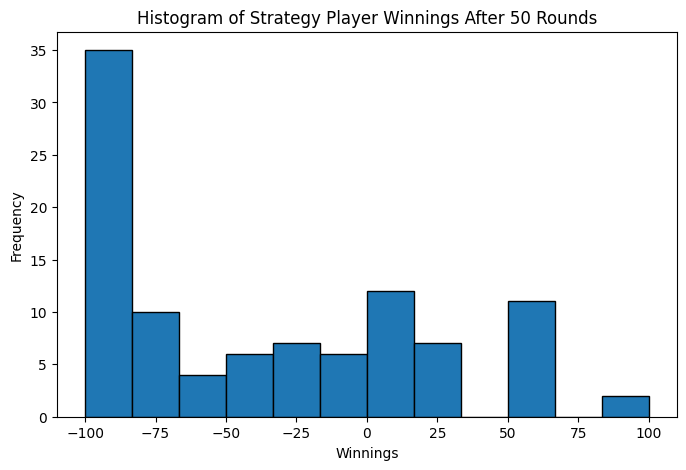

In [22]:
# Test cell
# Print the statistics and draw the histogram.

print("Average winnings after 50 rounds:", round(part8_stats["average_winnings"], 2))
print("Average winnings per round:", round(part8_stats["average_per_round"], 2))
print("Standard deviation of winnings:", round(part8_stats["std_dev"], 2))
print("Probability of net win:", round(part8_stats["prob_net_win"], 3))
print("Probability of net loss:", round(part8_stats["prob_net_loss"], 3))
print("Probability of break even:", round(part8_stats["prob_break_even"], 3))

# Draw a histogram of the winnings
plt.figure(figsize=(8, 5))
plt.hist(part8_stats["winnings_list"], bins=12, edgecolor="black")
plt.title("Histogram of Strategy Player Winnings After 50 Rounds")
plt.xlabel("Winnings")
plt.ylabel("Frequency")
plt.show()

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

In [23]:
# Part 9
# In this part, I am testing several threshold values for the counting player.
# The reason for this is to see which threshold gives the best average winnings.
# A lower or higher threshold changes when the player decides to hit or stand.
# I will try at least 5 different threshold values, run many games for each one,
# and then compare the results.

def scan_thresholds(threshold_values, num_games=100, rounds_per_game=50, starting_chips=100):
    # This list will store the results for each threshold
    results = []
    
    # Test each threshold one by one
    for threshold in threshold_values:
        stats = simulate_many_games(
            num_games=num_games,
            threshold=threshold,
            rounds_per_game=rounds_per_game,
            starting_chips=starting_chips
        )
        
        # Store the most important information for comparison
        results.append({
            "threshold": threshold,
            "avg_winnings": stats["average_winnings"],
            "avg_per_round": stats["average_per_round"],
            "std_dev": stats["std_dev"],
            "prob_win": stats["prob_net_win"],
            "prob_loss": stats["prob_net_loss"]
        })
    
    # Find the threshold with the best average winnings
    best_result = max(results, key=lambda row: row["avg_winnings"])
    
    return results, best_result


# Try several threshold values
threshold_values = [-3, -2, -1, 0, 1, 2]

# Run the threshold scan for Part 9
part9_results, best_threshold_result = scan_thresholds(
    threshold_values=threshold_values,
    num_games=100,
    rounds_per_game=50,
    starting_chips=100
)

In [24]:
# Test cell 
# Print the results for each threshold and show which one did best.

for row in part9_results:
    print(
        f"Threshold {row['threshold']:>2} | "
        f"Avg winnings = {row['avg_winnings']:>7.2f} | "
        f"Avg/round = {row['avg_per_round']:>6.2f} | "
        f"Std Dev = {row['std_dev']:>7.2f} | "
        f"P(win) = {row['prob_win']:.3f}"
    )

print("\nBest threshold based on average winnings:")
print(best_threshold_result)

Threshold -3 | Avg winnings =  -54.90 | Avg/round =  -1.10 | Std Dev =   52.47 | P(win) = 0.200
Threshold -2 | Avg winnings =  -43.00 | Avg/round =  -0.86 | Std Dev =   52.75 | P(win) = 0.190
Threshold -1 | Avg winnings =  -32.90 | Avg/round =  -0.66 | Std Dev =   58.93 | P(win) = 0.280
Threshold  0 | Avg winnings =  -33.00 | Avg/round =  -0.66 | Std Dev =   53.58 | P(win) = 0.250
Threshold  1 | Avg winnings =  -28.40 | Avg/round =  -0.57 | Std Dev =   59.32 | P(win) = 0.260
Threshold  2 | Avg winnings =  -37.90 | Avg/round =  -0.76 | Std Dev =   60.15 | P(win) = 0.240

Best threshold based on average winnings:
{'threshold': 1, 'avg_winnings': -28.4, 'avg_per_round': -0.568, 'std_dev': 59.324868310009755, 'prob_win': 0.26, 'prob_loss': 0.71}


10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [25]:
# Part 10
# In this part, I am creating a new strategy to compare against the old one.
# The old strategy mainly used the running count with a simple threshold rule.
# For the new strategy, I want the player to be a little more careful:
# - always hit on 11 or less
# - always stand on 17 or more
# - for totals from 12 to 16, use the running count and threshold
# This makes the strategy a little smarter while still keeping it simple enough for the lab.

class CarefulCountingPlayer(Player):
    def __init__(self, name, chips=100, bet_amount=10, threshold=-1):
        # Use the normal Player setup first
        super().__init__(name, chips, bet_amount)
        
        # This threshold will control the hit/stand decision in the middle range
        self.threshold = threshold
    
    def running_count(self):
        # Add up the count values of all visible cards
        return sum(card.count_value() for card in self.shown_cards)
    
    def wants_hit(self, dealer_upcard=None):
        # Get the current hand total and running count
        total = self.hand.value()
        count = self.running_count()
        
        # Very small totals should always hit
        if total <= 11:
            return True
        
        # Strong totals should stand
        if total >= 17:
            return False
        
        # For middle totals, use the running count and threshold
        if 12 <= total <= 16:
            return count <= self.threshold
        
        return False


def run_new_strategy_game(threshold=-1, rounds=50, starting_chips=100, verbose=False):
    # Create the new strategy player
    strategy_player = CarefulCountingPlayer(
        name="Careful Counter",
        chips=starting_chips,
        bet_amount=10,
        threshold=threshold
    )
    
    # Create 3 regular players
    other_players = [
        Player("Other Player 1", chips=starting_chips),
        Player("Other Player 2", chips=starting_chips),
        Player("Other Player 3", chips=starting_chips)
    ]
    
    # Put everybody into the game
    game = BlackjackGame(
        players=[strategy_player] + other_players,
        verbose=verbose
    )
    
    # Play up to the requested number of rounds
    for _ in range(rounds):
        if strategy_player.chips < strategy_player.bet_amount:
            break
        
        played = game.play_round()
        if not played:
            break
    
    # Return final winnings
    return strategy_player.chips - starting_chips


def compare_old_and_new(num_games=100, rounds=50, old_threshold=0, new_threshold=-1):
    # Store results from both strategies
    old_results = []
    new_results = []
    
    # Run many games for each strategy
    for _ in range(num_games):
        old_game_result = run_single_strategy_game(
            threshold=old_threshold,
            rounds=rounds,
            starting_chips=100,
            verbose=False
        )
        old_results.append(old_game_result["winnings"])
        
        new_game_winnings = run_new_strategy_game(
            threshold=new_threshold,
            rounds=rounds,
            starting_chips=100,
            verbose=False
        )
        new_results.append(new_game_winnings)
    
    # Compute average winnings for both
    old_avg = sum(old_results) / len(old_results)
    new_avg = sum(new_results) / len(new_results)
    
    return {
        "old_avg": old_avg,
        "new_avg": new_avg,
        "difference": new_avg - old_avg,
        "old_results": old_results,
        "new_results": new_results
    }


# Run the comparison for Part 10
part10_comparison = compare_old_and_new(
    num_games=100,
    rounds=50,
    old_threshold=0,
    new_threshold=-1
)

In [26]:
# Test cell 
# Print the average performance of both strategies and compare them.

print("Old strategy average winnings:", round(part10_comparison["old_avg"], 2))
print("New strategy average winnings:", round(part10_comparison["new_avg"], 2))
print("Difference (new - old):", round(part10_comparison["difference"], 2))

if part10_comparison["difference"] > 0:
    print("The new strategy performed better on average.")
elif part10_comparison["difference"] < 0:
    print("The old strategy performed better on average.")
else:
    print("Both strategies performed about the same in this simulation.")

Old strategy average winnings: -35.3
New strategy average winnings: -32.0
Difference (new - old): 3.3
The new strategy performed better on average.
